In [1]:
# Import required packages
import numpy as np
import matplotlib.pyplot as plt
from qsopt.core.experimental_parameters import (
    ExperimentalParameters,
    PhysicalConstants,
    SystemDimensions,
    MeasurementProtocol,
    InitialStateConfig,
    InteractionType,
    InitialStateType
)
from qsopt.core.trainable_parameters import TrainableParameters
from qsopt.core.experiment import SingleQubitExperiment, TwoQubitExperiment
from qsopt.utils import plot_single_probability_map, plot_two_qubit_probabilities, plot_qubit_time_evolution

np.random.seed(42)

1. **Single Qubit**: Evolution over time and chi-gamma parameter sweep
2. **Two Uncoupled Qubits**: Final state probabilities P(00), P(01), P(10), P(11) vs chi-gamma
3. **Two Coupled Qubits**: Effects of qubit-qubit interaction on final state distributions

## Single Qubit


In [2]:
# Single Qubit Experiment Setup
phys_const_1q = PhysicalConstants(
    n_qubits=1,
    chi=[5.0],  # Dispersive coupling
    photon_cavity_coupling=10.0,  # gamma
    inverse_pulse_width=1.0  # sigma (pulse width parameter)
)

sys_dims_1q = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=[2]
)

meas_protocol_1q = MeasurementProtocol(
    measurement_times=[-5., 5.],
    initial_time_uncertainty=0.0
)

initial_state_1q = InitialStateConfig(state_type=InitialStateType.SINGLE_PHOTON)

exp_params_1q = ExperimentalParameters(
    physical_constants=phys_const_1q,
    system_dims=sys_dims_1q,
    measurement=meas_protocol_1q,
    initial_state=initial_state_1q
)

train_params_1q = TrainableParameters()
train_params_1q.add_rotation_angles(['ry1', 'ry2'], [np.pi/2, -np.pi/2])

# Create experiment
exp_1q = SingleQubitExperiment(exp_params_1q, train_params_1q)

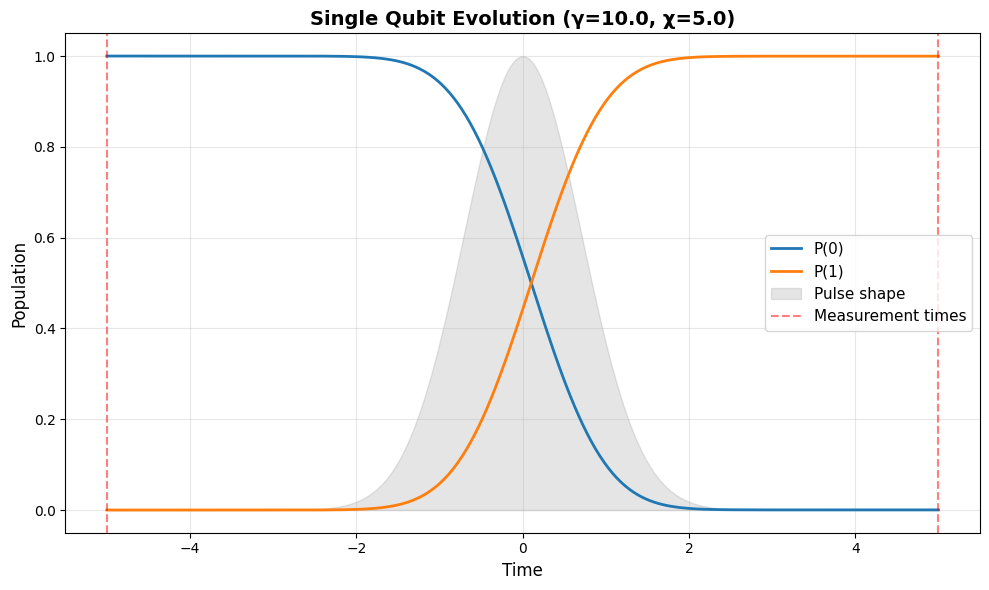

In [3]:
# Single Qubit: Time evolution

results_1q_time = exp_1q.time_evolution(t_start=-5.0, t_end=5.0, n_points=200, with_interaction=True)

plot_qubit_time_evolution(
    results_1q_time['times'],
    {'prob_0': results_1q_time['prob_0'], 'prob_1': results_1q_time['prob_1']},
    pulse_shape=results_1q_time['pulse_shape'],
    measurement_times=exp_1q.experimental_params.measurement.measurement_times,
    title=f'Single Qubit Evolution (γ={phys_const_1q.photon_cavity_coupling}, χ={phys_const_1q.chi[0]})',
    figsize=(10, 6)
)
plt.show()

Now we sweep over chi and gamma parameters to find the optimal sensing configuration.
This reproduces the contour plot from the reference notebook.

In [5]:
results_1q_sweep = exp_1q.sweep_chi_gamma(
    chi_interval=[0., 10.0],
    gamma_interval=[0.1, 20.0],
    resolution_chi=10,
    resolution_gamma=10,
    chi_scale='linear',
    gamma_scale='linear',
    batch_size=1,
    verbose=True
)

Computing χ-γ parameter sweep...
  Resolution: 10×10 = 100 points
  χ range: [0.00, 10.00] (linear scale)
  γ range: [0.10, 20.00] (linear scale)


c:\users\simon\code\quantum-sensing-qml\src\qsopt\core\experimental_parameters.py:452: UserWarning: Dispersive coupling (chi) for qubit 0 is zero. This means no qubit-cavity interaction for this qubit, which may not produce meaningful sensing results.
  warnings.warn(
c:\users\simon\code\quantum-sensing-qml\src\qsopt\core\experimental_parameters.py:452: UserWarning: Dispersive coupling (chi) for qubit 0 is zero. This means no qubit-cavity interaction for this qubit, which may not produce meaningful sensing results.
  warnings.warn(
c:\users\simon\code\quantum-sensing-qml\src\qsopt\core\experimental_parameters.py:452: UserWarning: Dispersive coupling (chi) for qubit 0 is zero. This means no qubit-cavity interaction for this qubit, which may not produce meaningful sensing results.
  warnings.warn(
c:\users\simon\code\quantum-sensing-qml\src\qsopt\core\experimental_parameters.py:452: UserWarning: Dispersive coupling (chi) for qubit 0 is zero. This means no qubit-cavity interaction for thi

  Progress: 10.0% | Elapsed: 9.7s
  Progress: 20.0% | Elapsed: 19.7s
  Progress: 20.0% | Elapsed: 19.7s
  Progress: 30.0% | Elapsed: 29.9s
  Progress: 30.0% | Elapsed: 29.9s
  Progress: 40.0% | Elapsed: 40.0s
  Progress: 40.0% | Elapsed: 40.0s
  Progress: 50.0% | Elapsed: 50.2s
  Progress: 50.0% | Elapsed: 50.2s
  Progress: 60.0% | Elapsed: 60.5s
  Progress: 60.0% | Elapsed: 60.5s
  Progress: 70.0% | Elapsed: 70.8s
  Progress: 70.0% | Elapsed: 70.8s
  Progress: 80.0% | Elapsed: 81.4s
  Progress: 80.0% | Elapsed: 81.4s
  Progress: 90.0% | Elapsed: 91.9s
  Progress: 90.0% | Elapsed: 91.9s
  Progress: 100.0% | Elapsed: 102.7s
✓ Sweep completed in 102.7s
  Max contrast: 0.999981
  Optimal χ: 10.000
  Optimal γ: 20.000
  Progress: 100.0% | Elapsed: 102.7s
✓ Sweep completed in 102.7s
  Max contrast: 0.999981
  Optimal χ: 10.000
  Optimal γ: 20.000


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


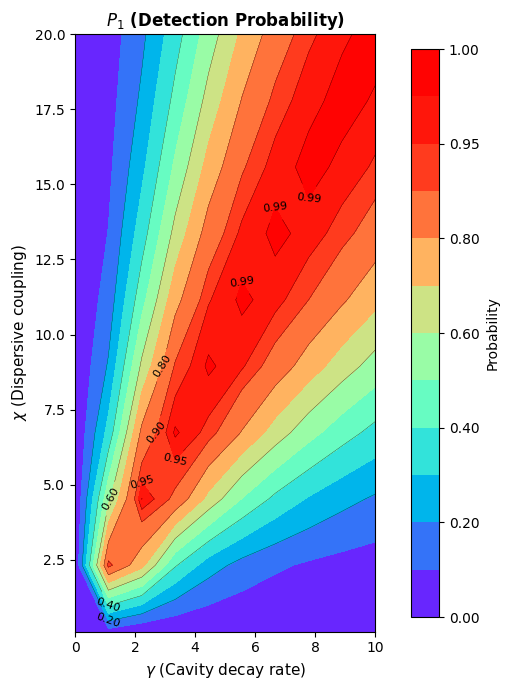

In [6]:
plot_single_probability_map(
    results_1q_sweep['chi_vals'],
    results_1q_sweep['gamma_vals'],
    results_1q_sweep['detection_map'],
    title=r'$P_1$ (Detection Probability)',
    xlabel=r'$\gamma$ (Cavity decay rate)',
    ylabel=r'$\chi$ (Dispersive coupling)',
    chi_scale='linear',
    gamma_scale='linear',
    figsize=(8, 7)
)
plt.show()

## Two Uncoupled Qubits

Now we move to two-qubit experiments. First, we consider two qubits that are **not** coupled to each other 
(only coupled to the cavity).
We'll plot all four final state probabilities: P(00), P(01), P(10), P(11).

In [11]:
phys_const_2q = PhysicalConstants(
    n_qubits=2,
    chi=[40.0, 40.0],  # Equal dispersive coupling for both qubits
    photon_cavity_coupling=10.0,  # gamma
    inverse_pulse_width=1.0,
    qubit_interactions=[]  # No qubit-qubit coupling (chi12=0)
)

sys_dims_2q = SystemDimensions(
    field_levels=2,
    cavity_levels=2,
    qubit_levels=[2, 2]
)

meas_protocol_2q = MeasurementProtocol(
    measurement_times=[-5, 5],
)

initial_state_2q = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

exp_params_2q = ExperimentalParameters(
    physical_constants=phys_const_2q,
    system_dims=sys_dims_2q,
    measurement=meas_protocol_2q,
    initial_state=initial_state_2q
)

# Rotation parameters for both qubits (theta1_q1, theta2_q1, theta1_q2, theta2_q2)
train_params_2q = TrainableParameters()
train_params_2q.add_rotation_angles(
    ["theta1_q1", "theta2_q1", "theta1_q2", "theta2_q2"],
    [np.pi/2, -np.pi/2, np.pi/2, -np.pi/2]
)

# Create experiment with default detector (1-P(00))
exp_2q_uncoupled = TwoQubitExperiment(exp_params_2q, train_params_2q)

Time evolution plot saved to: two_uncoupled_qubits_evolution.png


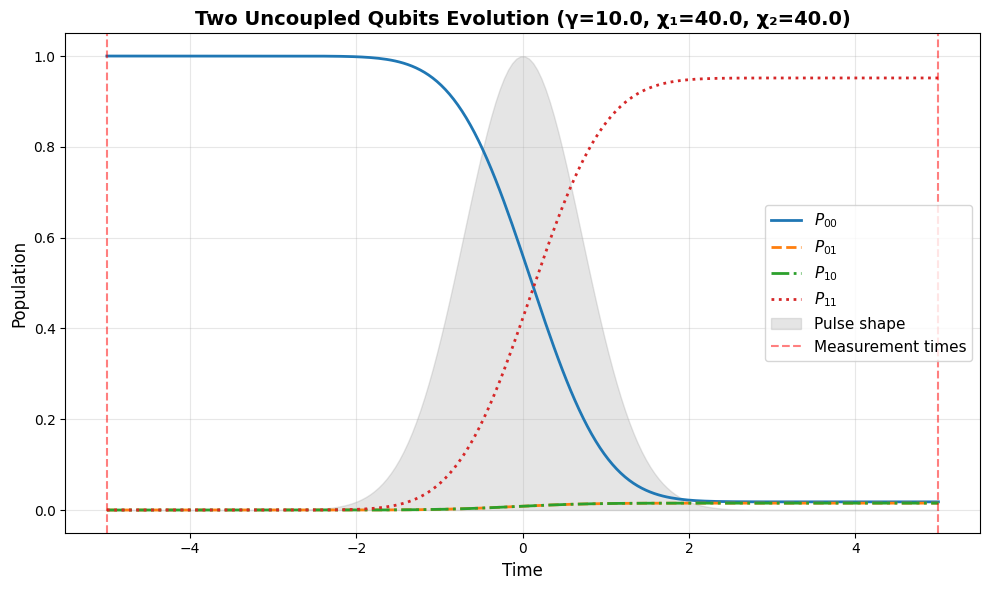

In [12]:
# Two Uncoupled Qubits: Time evolution
results_2q_time = exp_2q_uncoupled.time_evolution(t_start=-5.0, t_end=5.0, n_points=200)

plot_qubit_time_evolution(
    results_2q_time['times'],
    {
        'prob_00': results_2q_time['prob_00'],
        'prob_01': results_2q_time['prob_01'],
        'prob_10': results_2q_time['prob_10'],
        'prob_11': results_2q_time['prob_11']
    },
    pulse_shape=results_2q_time['pulse_shape'],
    measurement_times=exp_2q_uncoupled.experimental_params.measurement.measurement_times,
    title=f'Two Uncoupled Qubits Evolution (γ={phys_const_2q.photon_cavity_coupling}, χ₁={phys_const_2q.chi[0]}, χ₂={phys_const_2q.chi[1]})',
    figsize=(10, 6),
    save_path='two_uncoupled_qubits_evolution.png'
)
plt.show()

## Two Uncoupled Qubits: Chi-Gamma Sweep

We now sweep over chi and gamma to see all four probability maps as in the reference notebook.

In [ ]:
# Two Uncoupled Qubits: Chi-Gamma Sweep
# Sweep chi from 0-50, with gamma fixed at 10

results_2q_sweep = exp_2q_uncoupled.sweep_chi_gamma(
    chi_interval=[0.1, 50.0],
    gamma_interval=[0.1, 20.0],
    resolution_chi=30,
    resolution_gamma=30,
    chi_scale='linear',
    gamma_scale='linear',
    batch_size=1,
    verbose=True
)

In [ ]:
# Plot all four probability maps in 2x2 grid
plot_two_qubit_probabilities(
    results_2q_sweep['chi_vals'],
    results_2q_sweep['gamma_vals'],
    results_2q_sweep['prob_maps'],
    chi_scale='linear',
    gamma_scale='linear',
    figsize=(12, 12)
)
plt.show()

## Two Coupled Qubits

Now we add qubit-qubit interaction (chi12 ≠ 0). This reproduces the "Due qubit accoppiati" section.

We'll use an XX interaction (σx⊗σx) between the qubits with coupling strength chi12 = 10*gamma.

In [ ]:
# Two Qubit Experiment Setup (Coupled)
# Add XX interaction between qubits

from qsopt.core.experimental_parameters import QubitInteraction

# Create qubit interaction: chi12 = 10 * gamma = 100
qubit_interaction = QubitInteraction(
    qubit_indices=(0, 1),  # Between qubit 1 and qubit 2
    chi=100.0,  # 10 * gamma
    interaction_type=InteractionType.XX  # σx ⊗ σx interaction
)

phys_const_2q_coupled = PhysicalConstants(
    n_qubits=2,
    chi=[50.0, 50.0],  # Equal dispersive coupling
    photon_cavity_coupling=10.0,  # gamma
    inverse_pulse_width=1.0,
    qubit_interactions=[qubit_interaction]  # Add coupling
)

exp_params_2q_coupled = ExperimentalParameters(
    physical_constants=phys_const_2q_coupled,
    system_dims=sys_dims_2q,
    measurement=meas_config_2q,
    initial_state=initial_state_2q
)

exp_2q_coupled = TwoQubitExperiment(exp_params_2q_coupled, train_params_2q)
print(f"✓ Two-qubit coupled experiment created with χ₁₂={qubit_interaction.chi}")

In [ ]:
# Two Coupled Qubits: Chi-Gamma Sweep
results_2q_coupled_sweep = exp_2q_coupled.sweep_chi_gamma(
    chi_interval=[0.1, 50.0],
    gamma_interval=[0.1, 20.0],
    resolution_chi=30,
    resolution_gamma=30,
    chi_scale='linear',
    gamma_scale='linear',
    batch_size=1,
    verbose=True
)

# Plot all four probability maps
plot_two_qubit_probabilities(
    results_2q_coupled_sweep['chi_vals'],
    results_2q_coupled_sweep['gamma_vals'],
    results_2q_coupled_sweep['prob_maps'],
    chi_scale='linear',
    gamma_scale='linear',
    figsize=(12, 12)
)
plt.suptitle('Two Coupled Qubits (χ₁₂=100)', fontsize=16, fontweight='bold', y=0.998)
plt.show()

## Comparison: Coupled vs Uncoupled

Let's compare P(11) for coupled vs uncoupled qubits side by side.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

Chi, Gamma = np.meshgrid(results_2q_sweep['chi_vals'], results_2q_sweep['gamma_vals'])
contour_levels = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0]
label_levels = [0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0]

# Uncoupled
ax = axes[0]
cf = ax.contourf(Chi, Gamma, results_2q_sweep['prob_maps']['p11'], 
                 levels=contour_levels, cmap='rainbow')
plt.colorbar(cf, ax=ax, fraction=0.04, label='Probability')
cs = ax.contour(Chi, Gamma, results_2q_sweep['prob_maps']['p11'], 
                levels=label_levels, colors='k', linewidths=0.2)
ax.clabel(cs, inline=True, fontsize=8)
ax.set_xlabel(r'$\chi$ (Dispersive coupling)', fontsize=12)
ax.set_ylabel(r'$\gamma$ (Cavity decay rate)', fontsize=12)
ax.set_title(r'$P_{11}$ Uncoupled ($\chi_{12}=0$)', fontsize=14, fontweight='bold')
ax.set_aspect('equal', adjustable='box')

# Coupled
ax = axes[1]
cf = ax.contourf(Chi, Gamma, results_2q_coupled_sweep['prob_maps']['p11'], 
                 levels=contour_levels, cmap='rainbow')
plt.colorbar(cf, ax=ax, fraction=0.04, label='Probability')
cs = ax.contour(Chi, Gamma, results_2q_coupled_sweep['prob_maps']['p11'], 
                levels=label_levels, colors='k', linewidths=0.2)
ax.clabel(cs, inline=True, fontsize=8)
ax.set_xlabel(r'$\chi$ (Dispersive coupling)', fontsize=12)
ax.set_ylabel(r'$\gamma$ (Cavity decay rate)', fontsize=12)
ax.set_title(r'$P_{11}$ Coupled ($\chi_{12}=100$)', fontsize=14, fontweight='bold')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

## Summary

This notebook successfully recreates the key experiments from Fabio's reference notebook using the `qsopt` package:

### Key Features Demonstrated:

1. **Single Qubit Sensing**
   - Time evolution showing population transfer during the pulse
   - Chi-gamma parameter sweep showing optimal sensing regions
   - Detection probability P(1) varies with dispersive coupling and cavity decay

2. **Two Uncoupled Qubits**
   - All four joint measurement outcomes P(00), P(01), P(10), P(11)
   - Time evolution showing coherent dynamics of both qubits
   - Parameter sweeps revealing optimal configurations for different detection criteria

3. **Two Coupled Qubits**  
   - Effect of qubit-qubit interaction (XX coupling) on final state probabilities
   - Comparison with uncoupled case shows how chi12 modifies the probability landscape
   - Useful for understanding entanglement-based sensing protocols

### New Features in qsopt:

- **`DetectionFromProbabilities` class**: Flexible definition of detection criteria (1-P(00), P(11), etc.)
- **`run_simulation_with_probabilities()`**: Returns all final state probabilities for two-qubit systems
- **`plot_two_qubit_probabilities()`**: Visualizes all four probability maps in one figure
- **Probability maps in sweep results**: Two-qubit sweeps now include `prob_maps` dict with p00, p01, p10, p11

These tools enable reproduction of complex quantum sensing experiments and facilitate parameter optimization
for multi-qubit sensing protocols.